In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False

plt.style.use("ggplot")

In [2]:
df = pd.read_csv('jeju_bus.csv')

display(df.head())

print('shape:', df.shape)

print('전체 결측치 개수:', df.isnull().sum().sum())

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64


shape: (210457, 14)
전체 결측치 개수: 0


In [3]:
df_model = df.copy()

df_model['original_index'] = df_model.index
target_col = 'next_arrive_time'

In [4]:
df_model['date'] = pd.to_datetime(df_model['date'])

df_model['day'] = df_model['date'].dt.day
df_model['dayofweek'] = df_model['date'].dt.dayofweek

df_model['now_hour'] = df_model['now_arrive_time'].astype(str).str.extract(r'(\d+)').astype(float)

df_model[['date', 'day', 'dayofweek', 'now_arrive_time', 'now_hour']].head()

,date,day,dayofweek,now_arrive_time,now_hour
0,2019-10-15,15,1,06시,6.0
1,2019-10-15,15,1,06시,6.0
2,2019-10-15,15,1,06시,6.0
3,2019-10-15,15,1,06시,6.0
4,2019-10-15,15,1,07시,7.0


In [5]:
df_model['station_segment'] = (
    df_model['now_station'].astype(str) + ' → ' + df_model['next_station'].astype(str)
)
df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time,original_index,day,dayofweek,now_hour,station_segment
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24,0,15,1,6.0,제주대학교입구 → 제대마을
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36,1,15,1,6.0,제대마을 → 제대아파트
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40,2,15,1,6.0,제대아파트 → 제주대학교
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42,3,15,1,6.0,남국원(아라방면) → 제주여자중고등학교(아라방면)
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64,4,15,1,7.0,도호동 → 은남동


In [6]:
print('station_segment 고유값 개수:', df_model['station_segment'].nunique())

station_segment 고유값 개수: 724


In [7]:
def calculate_distance_km(lat1, lon1, lat2, lon2):
    # 위도/경도 사이의 거리를 km 단위로 계산!
    # 1: 현재 내 정류징
    # 2: 각 주요 지점
    earth_radius_km = 6371

    # radius: 반지름, 반
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    # 거리 계산 공식
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2        
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c

In [8]:
reference_points = {
    'up'    : (33.506286, 126.490312),
    'down'  : (33.246742, 126.562387),
    'right' : (33.493521, 126.895326),
    'center': (33.379724, 126.545315)
}

In [9]:
def assign_region_info(data, lat_col, lon_col):
    up_lat, up_lon = reference_points['up']
    down_lat, down_lon = reference_points['down']
    right_lat, right_lon = reference_points['right']
    center_lat, center_lon = reference_points['center']

    distance_to_up = calculate_distance_km(data[lat_col], data[lon_col], up_lat, up_lon)
    distance_to_down = calculate_distance_km(data[lat_col], data[lon_col], down_lat, down_lon)
    distance_to_right = calculate_distance_km(data[lat_col], data[lon_col], right_lat, right_lon)
    distance_to_center = calculate_distance_km(data[lat_col], data[lon_col], center_lat, center_lon)

    distance_table = pd.DataFrame({
        'up': distance_to_up,
        'down': distance_to_down,
        'right': distance_to_right,
        'center': distance_to_center        
    }, index = data.index)

    nearest_region = distance_table.idxmin(axis = 1)

    result = pd.DataFrame({
        'dist_name': nearest_region,
        'dist_to_up': distance_to_up,
        'dist_to_down': distance_to_down,
        'dist_to_right': distance_to_right,
        'dist_to_center': distance_to_center
    }, index = data.index)

    return result

In [10]:
now_region_info = assign_region_info(
    df_model,
    'now_latitude',
    'now_longitude'    
)

now_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,7.962505,23.319056,32.135034,8.532122
1,up,8.003869,23.473015,31.905930,8.710701
2,up,8.158338,23.582519,31.583874,8.861671
3,up,5.774762,25.961685,32.635035,11.118256
4,up,2.332803,27.295447,37.141639,12.673969


In [11]:
next_region_info = assign_region_info(
    df_model,
    'next_latitude',
    'next_longitude'    
)

next_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,8.003869,23.473015,31.905930,8.710701
1,up,8.158338,23.582519,31.583874,8.861671
2,up,8.387595,23.701416,31.175511,9.041978
3,up,5.429627,26.539110,32.693959,11.692688
4,up,2.276139,27.400941,37.514443,12.832868


In [12]:
df_model['now_dist_name'] = now_region_info['dist_name']
df_model['now_dist_to_up'] = now_region_info['dist_to_up']
df_model['now_dist_to_down'] = now_region_info['dist_to_down']
df_model['now_dist_to_right'] = now_region_info['dist_to_right']
df_model['now_dist_to_center'] = now_region_info['dist_to_center']

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,original_index,day,dayofweek,now_hour,station_segment,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,...,0,15,1,6.0,제주대학교입구 → 제대마을,up,7.962505,23.319056,32.135034,8.532122
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,...,1,15,1,6.0,제대마을 → 제대아파트,up,8.003869,23.473015,31.905930,8.710701
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,...,2,15,1,6.0,제대아파트 → 제주대학교,up,8.158338,23.582519,31.583874,8.861671
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,...,3,15,1,6.0,남국원(아라방면) → 제주여자중고등학교(아라방면),up,5.774762,25.961685,32.635035,11.118256
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,...,4,15,1,7.0,도호동 → 은남동,up,2.332803,27.295447,37.141639,12.673969


In [13]:
df_model['next_dist_name'] = next_region_info['dist_name']
df_model['next_dist_to_up'] = next_region_info['dist_to_up']
df_model['next_dist_to_down'] = next_region_info['dist_to_down']
df_model['next_dist_to_right'] = next_region_info['dist_to_right']
df_model['next_dist_to_center'] = next_region_info['dist_to_center']

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center,next_dist_name,next_dist_to_up,next_dist_to_down,next_dist_to_right,next_dist_to_center
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,...,up,7.962505,23.319056,32.135034,8.532122,up,8.003869,23.473015,31.905930,8.710701
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,...,up,8.003869,23.473015,31.905930,8.710701,up,8.158338,23.582519,31.583874,8.861671
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,...,up,8.158338,23.582519,31.583874,8.861671,up,8.387595,23.701416,31.175511,9.041978
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,...,up,5.774762,25.961685,32.635035,11.118256,up,5.429627,26.539110,32.693959,11.692688
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,...,up,2.332803,27.295447,37.141639,12.673969,up,2.276139,27.400941,37.514443,12.832868


In [14]:
df_model['dist_segment_name'] = (
    df_model['now_dist_name'].astype(str)
    + ' → '
    + df_model['next_dist_name'].astype(str)    
)

print('dist_segment_name 고유값 개수: ', df_model['dist_segment_name'].nunique())
df_model['dist_segment_name'].value_counts()

dist_segment_name 고유값 개수:  12


dist_segment_name
up → up            121131
down → down         48377
right → right       34032
center → center      5512
center → up           321
right → up            276
up → center           207
down → right          144
up → right            137
right → down          134
down → center          95
center → down          91
Name: count, dtype: int64

In [15]:
train_idx, test_idx = train_test_split(df_model.index, test_size = 0.2, random_state= 42)

In [16]:
train_idx

Index([ 83592,  90409, 120302,  51456, 155314,  31769, 150903,  54753,  45069,
        49676,
       ...
       168266, 137337,  54886, 207892, 110268, 119879, 103694, 131932, 146867,
       121958],
      dtype='int64', length=168365)

In [17]:
test_idx

Index([189257,  43886,  92321, 189283, 209076,  27323, 109278,  47463,  23537,
        32770,
       ...
       186918, 179953, 132509,  52355,  19216, 162060, 154838,  16730, 205199,
        51870],
      dtype='int64', length=42092)

In [18]:
print('train 행 수: ', len(train_idx), '/ test 행 수 : ', len(test_idx))

train 행 수:  168365 / test 행 수 :  42092


In [33]:
def evaluate_regression_model(model_name, experiment, y_true, y_pred,
                              directly_comparable = True, note = ''):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f'[{model_name}] MAE: {mae:.4f} | RMSE: {rmse:.4f} ')

    return {
        'model_name': model_name, 'experiment': experiment, 
        'directly_comparable': directly_comparable,
        'MAE': mae, 'RMSE': rmse, 'note': note
    }

In [78]:
"""
매개변수
- model_name: 결과 표에 표시할 모델
- experiment: 어떤 feature 구성을 썼는지에 대한 짧은 설명
ColumnTrnasformer
- remainder = 'passthrough': 나머지 숫자형 feature는 변환 없이 그대로 모델에 전달
XGBoost
- learning_rate: 한번에 얼마나 조금씩 보정할지(작을수록 신중하게 학습)
- objective: 회귀(제곱 오차를 줄이는 방향)으로 학습한다는 설정

"""
def train_xgb(model_name, experiment, numeric_features, categorical_features,
              train_idx, test_idx, data_df, directly_comparable=True, note = ''):
    feats = numeric_features + categorical_features
    X, y = data_df[feats], data_df[target_col]

    X_train, X_test= X.loc[train_idx], X.loc[test_idx]
    y_train, y_test= y.loc[train_idx], y.loc[test_idx]

    preprocessor = ColumnTransformer(
        transformers = [('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
        remainder = 'passthrough'        
    )

    model = XGBRegressor(n_estimators = 200, learning_rate = 0.05, max_depth = 5,
                         random_state=42, objective = 'reg:squarederror')

    pipe = Pipeline([('preprocessor',preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)    

    evaluation = evaluate_regression_model(model_name, experiment, y_test, y_pred,
                                            directly_comparable=directly_comparable, note=note)
    return {'pipeline': pipe, 'evaluation': evaluation, 'y_test': y_test, 'y_pred':y_pred}

In [37]:
numeric_features_v2 = ['distance', 'day', 'dayofweek', 'now_hour']
categorical_features_v2 = ['route_nm', 'now_station', 'next_station']

v2_result = train_xgb(
    model_name = 'v2_original', experiment = 'EDA 기반 v2 feature',
    numeric_features = numeric_features_v2, categorical_features = categorical_features_v2,
    train_idx = train_idx, test_idx = test_idx, data_df = df_model, note = '기준 모델'
)

[v2_original] MAE: 28.7086 | RMSE: 61.6643 


In [39]:
err = df_model.loc[test_idx].copy()
err['actual'] = v2_result['y_test'].values
err['pred'] = v2_result['y_pred']
err['abs_error'] = np.abs(err['actual'] - err['pred'])

err.sort_values('abs_error', ascending=False)[
    ['actual' ,'pred', 'abs_error', 'route_nm', 'now_station', 'next_station', 'now_hour', 'distance']
].head(20)

,actual,pred,abs_error,route_nm,now_station,next_station,now_hour,distance
150855,2906,41.793140,2864.206860,281-1,한국병원,제주버스터미널(가상정류소),8.0,188.0
125929,2888,94.179634,2793.820366,365-21,한라병원,삼무공원사거리,6.0,335.0
201187,2874,80.913696,2793.086304,365-22,제대아파트,제주대학교,18.0,415.0
158593,2882,96.446602,2785.553398,365-22,삼무공원사거리,한라병원,21.0,291.0
87813,2642,50.085686,2591.914314,201-26,서귀포버스터미널(가상정류소),대륜동주민센터,8.0,189.0
112140,2244,64.191193,2179.808807,365-22,노형오거리,남녕고등학교,6.0,252.0
141073,2234,98.249489,2135.750511,360-12,제대아파트,제대마을,15.0,334.0
76849,2160,48.718277,2111.281723,281-2,서귀포버스터미널(가상정류소),대륜동주민센터,18.0,189.0
62004,2160,80.780396,2079.219604,281-2,서귀포여자고등학교,수모루,18.0,746.0
4563,1986,64.191193,1921.808807,365-22,노형오거리,남녕고등학교,8.0,252.0


count    42092.000000
mean        28.708613
std         54.574503
min          0.002121
25%         11.195984
50%         21.588070
75%         34.603176
max       2864.206860
Name: abs_error, dtype: float64

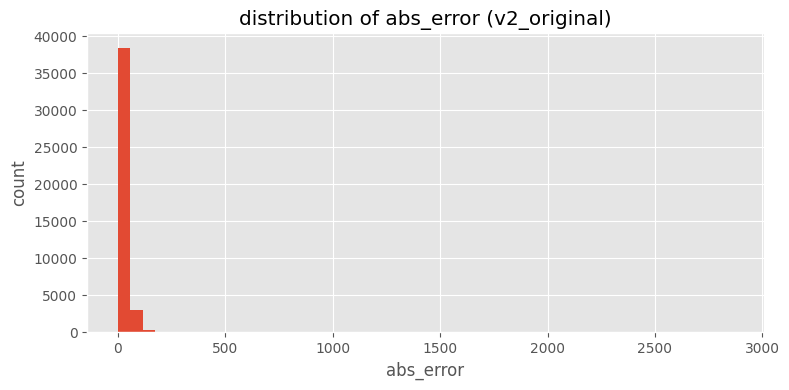

In [42]:
display(err['abs_error'].describe())

plt.figure(figsize=(8, 4))
plt.hist(err['abs_error'], bins = 50)
plt.title('distribution of abs_error (v2_original)')
plt.xlabel('abs_error');plt.ylabel('count')
plt.tight_layout(); plt.show()

,count,mean
now_hour,,
0.0,2,26.492420
5.0,105,111.828191
6.0,1639,31.797322
7.0,2694,28.042671
8.0,2750,30.937369
9.0,2735,26.424311
10.0,2565,27.586371
11.0,2521,26.255026
12.0,2791,27.675527


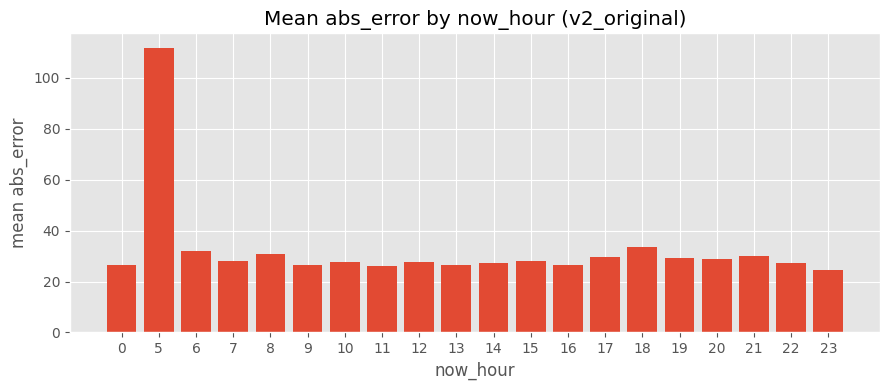

In [43]:
hour_error = err.groupby('now_hour')['abs_error'].agg(['count', 'mean']).sort_index()
display(hour_error)

plt.figure(figsize=(9, 4))
plt.bar(hour_error.index.astype(int).astype(str), hour_error['mean'])
plt.title('Mean abs_error by now_hour (v2_original)')
plt.xlabel('now_hour');plt.ylabel('mean abs_error')
plt.tight_layout(); plt.show()

In [49]:
upper_1pct = df_model[target_col].quantile(0.99)
df_no_outlier = df_model[df_model[target_col] <= upper_1pct].copy()
removed = len(df_model) - len(df_no_outlier)
print(f'상위 1% 경계값: {upper_1pct:.2f} / 제거 {removed}건 ({removed/len(df_model)*100:.2f})%)')

tr_no, te_no = train_test_split(df_no_outlier.index, test_size = 0.2, random_state=42)

v2_no_outlier_result = train_xgb(
    model_name = 'v2_without_top_1pct_target', experiment = 'v2 feature (동일)',
    numeric_features = numeric_features_v2, categorical_features = categorical_features_v2,
    train_idx = tr_no, test_idx = te_no, data_df = df_no_outlier, 
    directly_comparable=False,
    note = '평가 대상이 달라 직접 비교 주의'
)

상위 1% 경계값: 340.00 / 제거 2102건 (1.00)%)
[v2_without_top_1pct_target] MAE: 24.7411 | RMSE: 33.0449 


In [50]:
numeric_features_station = ['distance', 'day', 'dayofweek', 'now_hour']
categorical_features_station = ['route_nm', 'now_station', 'next_station', 'station_segment']

tr_no, te_no = train_test_split(df_no_outlier.index, test_size = 0.2, random_state=42)

v3_result = train_xgb(
    model_name = 'v3_with_station_segment', experiment = 'v2 + station_segment',
    numeric_features = numeric_features_station, categorical_features = categorical_features_station,
    train_idx = train_idx, test_idx = test_idx, data_df = df_model, 
    note = '정류장 구간 feature 추가, feature 수 증가'
)

[v3_with_station_segment] MAE: 28.7800 | RMSE: 61.6812 


In [52]:
try:
    n2 = len(v2_result['pipeline'].named_steps['preprocessor'].get_feature_names_out())
    n3 = len(v3_result['pipeline'].named_steps['preprocessor'].get_feature_names_out())
    print(f'v2_original 전처리 후 feature 수: {n2}')
    print(f'v3_with_station_segment 전처리 후 feature 수: {n3}  (증가: {n3 - n2})')
except Exception as e:
    print('feature 수 확인 중 문제가 발생했습니다:', e)

v2_original 전처리 후 feature 수: 724
v3_with_station_segment 전처리 후 feature 수: 1444  (증가: 720)


In [61]:
numeric_features_dist = [
     'distance', 'day', 'dayofweek', 'now_hour',
    'now_dist_to_up', 'now_dist_to_down', 'now_dist_to_right', 'now_dist_to_center',
    'next_dist_to_up', 'next_dist_to_down', 'next_dist_to_right', 'next_dist_to_center' 
]

categorical_features_dist = ['route_nm','now_station','next_station','dist_segment_name']

v2_dist_result = train_xgb(
    model_name = 'v2_with_dist_segment_name', experiment = 'v2 + segment_name',
    numeric_features = numeric_features_dist, categorical_features = categorical_features_dist,
    train_idx = train_idx, test_idx = test_idx, data_df = df_model, 
    note = '위치 권역 조합 feature 추가'
)

[v2_with_dist_segment_name] MAE: 26.2928 | RMSE: 60.2028 


In [70]:
comparison_df = pd.DataFrame([
    v2_result['evaluation'],
    v2_no_outlier_result['evaluation'],
    v3_result['evaluation'],
    v2_dist_result['evaluation'],
])

comparison_df[['model_name', 'experiment', 'directly_comparable', 'MAE', 'RMSE', 'note']]

,model_name,experiment,directly_comparable,MAE,RMSE,note
0,v2_original,EDA 기반 v2 feature,True,28.708614,61.664331,기준 모델
1,v2_without_top_1pct_target,v2 feature (동일),False,24.741096,33.044902,평가 대상이 달라 직접 비교 주의
2,v3_with_station_segment,v2 + station_segment,True,28.780006,61.681185,"정류장 구간 feature 추가, feature 수 증가"
3,v2_with_dist_segment_name,v2 + segment_name,True,26.292803,60.202784,위치 권역 조합 feature 추가


In [71]:
comparable_df = comparison_df[comparision_df['directly_comparable'] == True].sort_values('MAE')
comparable_df[['model_name', 'experiment', 'MAE', 'RMSE', 'note']]

,model_name,experiment,MAE,RMSE,note
3,v2_with_dist_segment_name,v2 + segment_name,26.292803,60.202784,위치 권역 조합 feature 추가
0,v2_original,EDA 기반 v2 feature,28.708614,61.664331,기준 모델
2,v3_with_station_segment,v2 + station_segment,28.780006,61.681185,"정류장 구간 feature 추가, feature 수 증가"


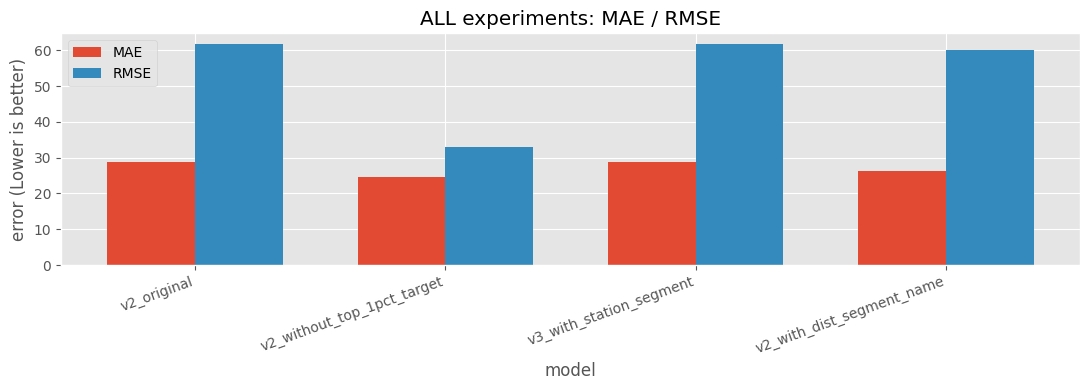

In [75]:
names = comparision_df['model_name'].tolist()
x = np.arange(len(names)); width = 0.35

plt.figure(figsize=(11, 4))
plt.bar(x - width/2, comparison_df['MAE'], width, label = 'MAE')
plt.bar(x + width/2, comparison_df['RMSE'], width, label = 'RMSE')
plt.title('ALL experiments: MAE / RMSE')
plt.xlabel('model');plt.ylabel('error (Lower is better)')
plt.xticks(x, names, rotation=20, ha='right');
plt.legend()
plt.tight_layout(); plt.show()

In [77]:
ci = comparison_df.set_index('model_name')
base = ci.loc['v2_original']
targets = comparison_df[(comparison_df['directly_comparable']) &
                        (comparison_df['model_name'] != 'v2_original')]['model_name'].tolist()

rows = [{
    'model_name' : name,
    'MAE_diff_vs_v2': ci.loc[name, 'MAE'] - base['MAE'],
    'RMSE_diff_vs_v2': ci.loc[name, 'RMSE'] - base['RMSE'],
} for name in targets]

print('차이 계산 대상: ', targets)
print("차이 계산 제외(평가 조건 다름): ['v2_without_top_1pct_target']")
pd.DataFrame(rows)

차이 계산 대상:  ['v3_with_station_segment', 'v2_with_dist_segment_name']
차이 계산 제외(평가 조건 다름): ['v2_without_top_1pct_target']


,model_name,MAE_diff_vs_v2,RMSE_diff_vs_v2
0,v3_with_station_segment,0.071392,0.016854
1,v2_with_dist_segment_name,-2.415812,-1.461547


reference_points['up']

up_lat, up_lon = reference_points['up']
print(f'up_lat = {up_lat}, up_lon = {up_lon}')

data = df_model.copy()

data

lat_col = 'now_latitude'
lon_col = 'now_longitude'

data[lat_col]

data[lon_col]

distance_to_up = calculate_distance_km(
                        data[lat_col], data[lon_col],
                        up_lat, up_lon
                    )

distance_to_up.tail(10)

distance_table = pd.DataFrame({
                            'up': distance_to_up,
                            'down': 5,
                            'right': 4,
                            'center': 3
                        }, index = data.index)

distance_table

distance_table[0:10].min(axis = 1)

nearest_region = distance_table.idxmin(axis = 1)

nearest_region.value_counts()

train_idx, test_idx = train_test_split(
                              df_model.index,
                              test_size = 0.2, 
                              random_state = 42
                        )

train_idx

test_idx

y_true_df = pd.DataFrame({
                'col':[100, 200, 300]
                })

y_true_df

y_pred_df = pd.DataFrame({
                         'col':[150, 180, 310]
            })

y_pred_df

np.absolute(y_true_df - y_pred_df).sum() / len(np.absolute(y_true_df - y_pred_df) )

mean_absolute_error(y_true_df, y_pred_df)

np.sqrt( ( (y_true_df - y_pred_df) ** 2).sum()  / len( (y_true_df - y_pred_df) ))

np.sqrt(mean_squared_error(y_true_df, y_pred_df))